In [16]:
from google.colab import files

uploaded = files.upload()


Saving test_catvnoncat.h5 to test_catvnoncat (1).h5
Saving train_catvnoncat.h5 to train_catvnoncat (1).h5


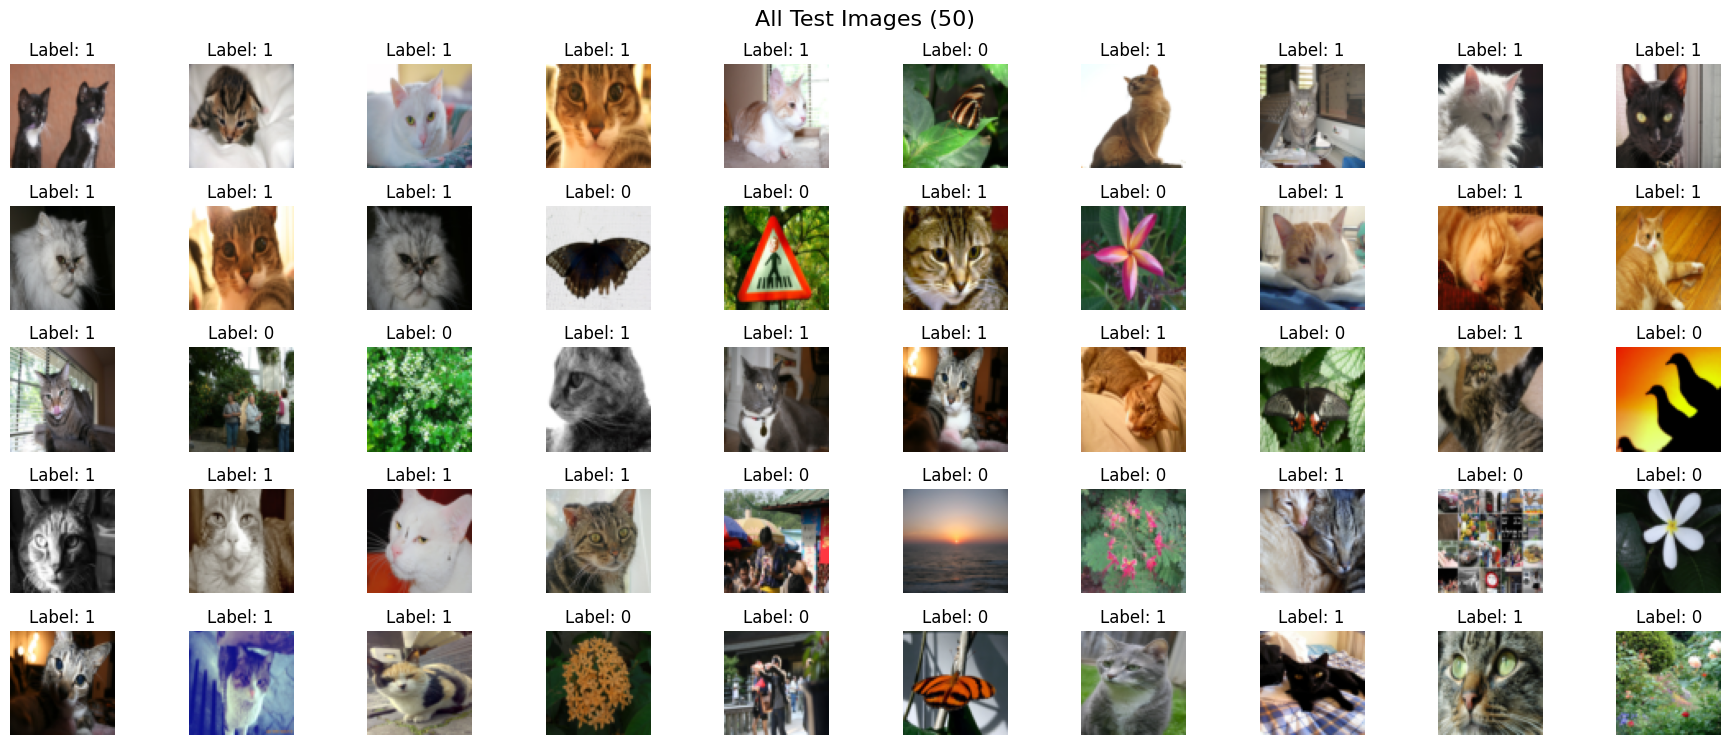

In [25]:

# Display ALL test images in a grid

import matplotlib.pyplot as plt

num_images = test_x.shape[0]       # 50
cols = 10                          # 10 images per row
rows = num_images // cols + 1

plt.figure(figsize=(18, 9))

for i in range(num_images):
    plt.subplot(rows, cols, i + 1)
    plt.imshow(test_x[i])
    plt.title(f"Label: {test_y[i]}")
    plt.axis("off")

plt.suptitle("All Test Images (50)", fontsize=16)
plt.tight_layout()
plt.show()


In [23]:
# Imports and basic setup
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset

import h5py
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report
from torchvision import transforms, models

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# Image preprocessing pipeline for ResNet18
transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])


# Dataset class for loading images and labels
class CatDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images = images
        self.labels = labels
        self.transform = transform

    def __len__(self):
        return self.images.shape[0]

    def __getitem__(self, idx):
        img = self.images[idx].astype(np.uint8)
        label = self.labels[idx]

        if self.transform is not None:
            img = self.transform(img)

        label = torch.tensor(label, dtype=torch.float32)
        return img, label


# Load the HDF5 files
with h5py.File("train_catvnoncat.h5", "r") as f:
    train_x = np.array(f["train_set_x"])
    train_y = np.array(f["train_set_y"])

with h5py.File("test_catvnoncat.h5", "r") as f:
    test_x = np.array(f["test_set_x"])
    test_y = np.array(f["test_set_y"])

print("Train images:", train_x.shape, " Train labels:", train_y.shape)
print("Test  images:", test_x.shape,  " Test labels:", test_y.shape)

# Create dataset objects
train_dataset = CatDataset(train_x, train_y, transform=transform)
test_dataset  = CatDataset(test_x,  test_y,  transform=transform)

# DataLoaders for batching the data
batch_size = 16
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)


# Build the ResNet18 model
model = models.resnet18(pretrained=True)
num_features = model.fc.in_features
model.fc = nn.Linear(num_features, 1)   # binary classification layer

model = model.to(device)

# Loss function and optimizer
criterion = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-5)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=1e-6)

num_epochs = 5


# Task 1 training loop
for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    total_train = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        total_train += images.size(0)

    scheduler.step()
    epoch_loss = running_loss / total_train
    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {epoch_loss:.4f}")


# Compute accuracy on train and test sets
model.eval()
all_train_preds, all_train_labels = [], []
all_test_preds,  all_test_labels  = [], []

with torch.no_grad():
    # Predictions on the training set
    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_train_preds.extend(preds.cpu().numpy().flatten())
        all_train_labels.extend(labels.cpu().numpy().flatten())

    # Predictions on the test set
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        all_test_preds.extend(preds.cpu().numpy().flatten())
        all_test_labels.extend(labels.cpu().numpy().flatten())

# Turn lists into numpy arrays
all_train_preds = np.array(all_train_preds)
all_train_labels = np.array(all_train_labels)
all_test_preds  = np.array(all_test_preds)
all_test_labels = np.array(all_test_labels)

# Calculate accuracy
train_accuracy = np.mean(all_train_preds == all_train_labels)
test_accuracy  = np.mean(all_test_preds  == all_test_labels)

print(f"Training Accuracy: {train_accuracy:.2f}")
print(f"Testing Accuracy:  {test_accuracy:.2f}\n")

print("Classification report on test set:")
print(classification_report(all_test_labels, all_test_preds,
                            target_names=["non-cat", "cat"]))


# Task 2: find misclassified test indices
misclassified_indices = []
idx = 0

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device).unsqueeze(1)

        outputs = model(images)
        probs = torch.sigmoid(outputs)
        preds = (probs > 0.5).float()

        preds_np  = preds.cpu().numpy().flatten()
        labels_np = labels.cpu().numpy().flatten()

        # Check each prediction
        batch_size = labels_np.shape[0]
        for i in range(batch_size):
            if preds_np[i] != labels_np[i]:
                misclassified_indices.append(idx + i)

        idx += batch_size

print("Misclassified test image indices:", misclassified_indices)


Using device: cpu
Train images: (209, 64, 64, 3)  Train labels: (209,)
Test  images: (50, 64, 64, 3)  Test labels: (50,)


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Epoch [1/5], Loss: 0.6581
Epoch [2/5], Loss: 0.4679
Epoch [3/5], Loss: 0.3284
Epoch [4/5], Loss: 0.2609
Epoch [5/5], Loss: 0.2075
Training Accuracy: 0.97
Testing Accuracy:  1.00

Classification report on test set:
              precision    recall  f1-score   support

     non-cat       1.00      1.00      1.00        17
         cat       1.00      1.00      1.00        33

    accuracy                           1.00        50
   macro avg       1.00      1.00      1.00        50
weighted avg       1.00      1.00      1.00        50

Misclassified test image indices (0-based): [29]


Showing misclassified test images...



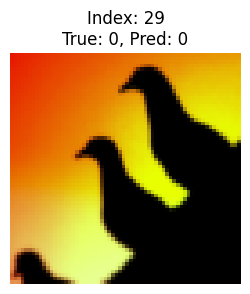

In [24]:
# Display misclassified test images
import matplotlib.pyplot as plt

if len(misclassified_indices) == 0:
    print("No misclassified images to display.")
else:
    print("Showing misclassified test images...\n")

    for idx in misclassified_indices:
        img = test_x[idx]
        true_label = test_y[idx]
        pred_label = int(all_test_preds[idx])

        plt.figure(figsize=(3, 3))
        plt.imshow(img)
        plt.title(f"Index: {idx}\nTrue: {true_label}, Pred: {pred_label}")
        plt.axis('off')
        plt.show()
